# Visualizing Data Augmentation Transforms
The goal of this notebook is to verify that the image transforms do not distort the training data beyond recognition.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import sys
from pathlib import Path

import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Add the project root to the path so we can import the config module
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../..'))

try:
    from garbage_classification.config import PROCESSED_DATA_DIR
except ModuleNotFoundError:
    print('Warning: Config not found. Falling back to default relative path.')
    PROCESSED_DATA_DIR = Path('../data/processed')

## Define Un-normalization Function

In [2]:
def unnormalize(tensor, mean, std):
    """
    Reverts the ImageNet normalization so the image can be displayed
    with its original colors (matplotlib expects values between 0 and 1).
    """
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)


## Load Data with Transforms

In [3]:
train_dir = PROCESSED_DATA_DIR / 'train'

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
classes = train_dataset.classes
print(f"Found classes: {classes}")


Found classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Visualization

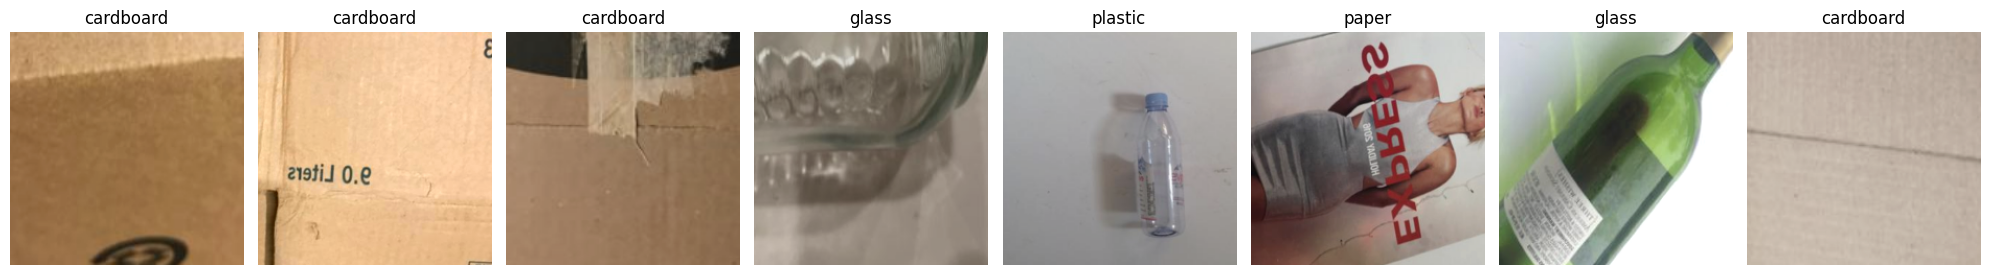

In [8]:
# Fetch a single batch of images and labels
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(20, 5))
for i in range(8):
    img_unnorm = unnormalize(
        images[i], 
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
    
    # PyTorch uses (Channels, Height, Width), but Matplotlib expects (Height, Width, Channels)
    img_np = img_unnorm.permute(1, 2, 0).numpy()
    
    axes[i].imshow(img_np)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()
